# Addestramento SFCN - Classificazione Binaria (Dataset OpenNeuro FCD)
Questo notebook adatta l'architettura SFCN per un task di **classificazione binaria** (es. HC vs FCD) utilizzando il dataset OpenNeuro.

**Caratteristiche Principali:**
1. **Architettura Ridotta**: Utilizza il trick dei canali ridotti `[28, 58, ...]` proposto dagli autori originali per limitare l'overfitting nei task binari. L'addestramento avviene **from scratch**.
2. **5-Fold Cross Validation**: Applicata sull'intero dataset per valutare in modo robusto le prestazioni (nessun test set separato, solo validation).


In [1]:
!rm -rf SFCN
!git clone https://github.com/PietroSchgor/SFCN.git

import sys
sys.path.append('./SFCN')

Cloning into 'SFCN'...
remote: Enumerating objects: 396, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 396 (delta 8), reused 8 (delta 8), pack-reused 379 (from 3)
Receiving objects: 100% (396/396), 146.78 MiB | 25.94 MiB/s, done.
Resolving deltas: 100% (190/190), done.


In [2]:
import os
import json
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

from dp_model.model_files.sfcn import SFCN

PLOTS_DIR = '/kaggle/working/plots'
os.makedirs(PLOTS_DIR, exist_ok=True)
MODELS_DIR = '/kaggle/working/models'
os.makedirs(MODELS_DIR, exist_ok=True)

## 1. Configurazione Parametri

In [3]:
KAGGLE_DATA_DIR = "/kaggle/input/datasets/elenaschgor/dataset-2-t1-flair/ds004199_final" # Dataset Reale

# --- MODALITA' CLINICA TARGET ---
# Scegli tra:
# - "T1w"   : Task T1 (utilizza automaticamente le immagini generate da "FLAIR to T1")
# - "FLAIR" : Task FLAIR (utilizza automaticamente le immagini generate da "T1 to FLAIR")
MODALITY = "FLAIR"

# --- LISTA DEGLI ESPERIMENTI DA ESEGUIRE IN SEQUENZA ---
# Ciascun esperimento allenera' la sua 5-Fold Cross Validation salvando checkpoint (.pth),
# curve di loss, matrici di confusione e file CSV con prefissi dedicati.
EXPERIMENTS_TO_RUN = [
    {
        "id": "gen_train_gen_val",
        "name": "Train Generato -> Val Generato (Sanity Check)",
        "train_mode": "only_generated",
        "validate_on_gen": True
    }
    # Opzionale: decommenta per eseguire anche la baseline pura reale nello stesso run:
    # {
    #     "id": "real_train_real_val",
    #     "name": "Train Reale -> Val Reale (Baseline)",
    #     "train_mode": "only_real",
    #     "validate_on_gen": False
    # }
]

CV_SPLITS_PATH = "/kaggle/input/datasets/collab2000/cv-split-epilessia/cv_splits_epilessia.txt" # File CSV con gli split salvati
GENERATIVE_MODEL = "eagan"        # Scegli tra "pix2pix", "eagan", "ptnet"

# Cartella delle immagini generate.
# Puoi indicare la cartella base (".../dataset 2/T1 - FLAIR") OPPURE direttamente la sottocartella (".../FLAIR to T1" o ".../T1 to FLAIR"):
# Il notebook selezionera' AUTOMATICAMENTE la cartella e i file corretti in base a MODALITY!
GENERATED_DATA_DIR = "/kaggle/input/datasets/collab2000/risultati-dataset-2/dataset 2/T1 - FLAIR"

# --- TOGGLE HISTOGRAM MATCHING (INTENSITY HARMONIZATION) ---
APPLY_HISTOGRAM_MATCHING = True   # Imposta a False per disattivare l'Histogram Matching
REF_SUBJECT_ID = "sub-00001"      # Soggetto reale di riferimento (presente in KAGGLE_DATA_DIR)

# --- CONFIGURAZIONE DELLA LOSS FUNCTION ---
# Scegli la funzione di perdita per l'esperimento:
# - "FOCAL"           : Focal Loss (gamma=2.0, focalizza il gradiente su casi difficili e riduce peso di campioni facili/artefatti)
# - "LABEL_SMOOTHING" : Label Smoothing Cross-Entropy (epsilon=0.1, previene overconfidence e migliora transfer generato->reale)
# - "FOCAL_SMOOTHED"  : Focal Loss combinata con Label Smoothing
# - "WEIGHTED_NLL"    : Weighted Negative Log-Likelihood
# - "NLL"             : Negative Log-Likelihood standard (Cross-Entropy classica baseline)
LOSS_TYPE = "NLL"

FOCAL_GAMMA = 2.0           # Esponente gamma per Focal Loss (default: 2.0)
LABEL_SMOOTHING_EPS = 0.1   # Epsilon per Label Smoothing (default: 0.1 -> target morbidi [0.05, 0.95])
CLASS_WEIGHTS = None        # Pesi classi opzionali (es. [1.0, 1.2])

# --- IMPOSTAZIONI K-FOLD E TRAINING ---
K_FOLDS = 5
OUTPUT_DIM = 2  # Classificazione Binaria (HC vs FCD)
EPOCHS = 150
BATCH_SIZE = 4
LR = 1e-4
WEIGHT_DECAY = 1e-3
PATIENCE = 20

# TRICK AUTORI: Canali ridotti per task binari
CUSTOM_CHANNELS = [28, 58, 128, 256, 256, 64]


## 2. Dataloader per OpenNeuro (Estrazione Label da JSON)

In [4]:
import os
import posixpath
import glob
import numpy as np
import nibabel as nib
import torch
from torch.utils.data import Dataset

def get_modality_info(modality):
    is_t1 = modality.lower() in ['t1w', 't1']
    if is_t1:
        direction = "FLAIR to T1"
        src_tag = "FLAIR"
        dst_tag = "T1"
    else:
        direction = "T1 to FLAIR"
        src_tag = "T1"
        dst_tag = "FLAIR"
    return is_t1, direction, src_tag, dst_tag

def resolve_generated_dir(gen_data_dir, direction):
    if not gen_data_dir:
        return gen_data_dir
    clean = gen_data_dir.replace(chr(92), '/').rstrip('/')
    base = posixpath.basename(clean).lower()
    if base in ['flair to t1', 't1 to flair']:
        clean = posixpath.dirname(clean)
    return posixpath.join(clean, direction)

def find_real_file(real_data_dir, sub, modality):
    if not real_data_dir or not os.path.exists(real_data_dir):
        return None
        
    is_t1, _, _, _ = get_modality_info(modality)
    sub_dir = os.path.join(real_data_dir, sub)
    search_dirs = [sub_dir] if os.path.exists(sub_dir) else [real_data_dir]
    
    if is_t1:
        candidates = [
            f"{sub}_{modality}_MNI152_1mm.nii",
            f"{sub}_{modality}_MNI152_1mm.nii.gz",
            f"{sub}_T1w_MNI152_1mm.nii",
            f"{sub}_T1w_MNI152_1mm.nii.gz",
            f"{sub}_T1_MNI152_1mm.nii",
            f"{sub}_T1_MNI152_1mm.nii.gz",
        ]
    else:
        candidates = [
            f"{sub}_{modality}_MNI152_1mm.nii",
            f"{sub}_{modality}_MNI152_1mm.nii.gz",
            f"{sub}_FLAIR_MNI152_1mm.nii",
            f"{sub}_FLAIR_MNI152_1mm.nii.gz",
            f"{sub}_flair_MNI152_1mm.nii",
            f"{sub}_flair_MNI152_1mm.nii.gz",
        ]
        
    for d in search_dirs:
        for c in candidates:
            p = os.path.join(d, c)
            if os.path.exists(p):
                return p
        if os.path.exists(d):
            try:
                mod_tag = 't1' if is_t1 else 'flair'
                for f in os.listdir(d):
                    if f.startswith(sub) and mod_tag in f.lower() and (f.endswith('.nii') or f.endswith('.nii.gz')):
                        return os.path.join(d, f)
            except Exception:
                pass
    return None

def find_generated_file(gen_data_dir, sub, gen_model, modality):
    if not gen_data_dir or not os.path.exists(gen_data_dir):
        return None
        
    _, direction, src_tag, dst_tag = get_modality_info(modality)
    gen_dir = resolve_generated_dir(gen_data_dir, direction)
    
    model_key = gen_model.lower()
    folder_candidates_map = {
        'eagan': ['Predizioni_EAGAN (1)', 'Predizioni_EAGAN', 'predizioni_eagan', 'EAGAN'],
        'pix2pix': ['Predizioni_Pix2Pix', 'Predizioni_Pix2Pix (1)', 'predizioni_pix2pix', 'Pix2Pix'],
        'ptnet': ['Predizioni_PTNet3D', 'Predizioni_PTNet3D (1)', 'Predizioni_PTNet', 'Predizioni_PTNet (1)', 'predizioni_ptnet3d', 'PTNet3D', 'PTNet']
    }
    target_folders = folder_candidates_map.get(model_key, [f'Predizioni_{gen_model}'])
    
    available_subdirs = []
    if os.path.exists(gen_dir):
        try:
            available_subdirs = [d for d in os.listdir(gen_dir) if os.path.isdir(os.path.join(gen_dir, d))]
        except Exception:
            available_subdirs = []
            
    folders_to_check = list(target_folders)
    for d in available_subdirs:
        if model_key in d.lower() and d not in folders_to_check:
            folders_to_check.append(d)
            
    model_tag_map = {
        'eagan': ['EAGAN', 'eagan'],
        'pix2pix': ['Pix2Pix', 'pix2pix', 'PIX2PIX'],
        'ptnet': ['PTNet', 'PTNet3D', 'ptnet', 'ptnet3d']
    }
    tags = model_tag_map.get(model_key, [gen_model])
    
    file_patterns = []
    for tag in tags:
        file_patterns.extend([
            f"{sub}_{src_tag}_to_{tag}_{dst_tag}.nii",
            f"{sub}_{src_tag}_to_{tag}_{dst_tag}.nii.gz",
        ])
        if dst_tag == "T1":
            file_patterns.extend([
                f"{sub}_{src_tag}_to_{tag}_T1w.nii",
                f"{sub}_{src_tag}_to_{tag}_T1w.nii.gz",
            ])
            
    for fld in folders_to_check:
        fld_path = os.path.join(gen_dir, fld)
        if not os.path.exists(fld_path):
            continue
            
        for pat in file_patterns:
            p = os.path.join(fld_path, pat)
            if os.path.exists(p):
                return p
                
        try:
            for f in os.listdir(fld_path):
                if f.startswith(sub) and (f.endswith('.nii') or f.endswith('.nii.gz')):
                    if dst_tag.lower() in f.lower():
                        return os.path.join(fld_path, f)
        except Exception:
            pass
            
    for pat in file_patterns:
        p = os.path.join(gen_dir, pat)
        if os.path.exists(p):
            return p
            
    try:
        matches = glob.glob(os.path.join(gen_dir, "**", f"{sub}*.nii*"), recursive=True)
        for m in matches:
            if model_key in m.lower() and dst_tag.lower() in os.path.basename(m).lower():
                return m
        if matches:
            for m in matches:
                if model_key in m.lower():
                    return m
    except Exception:
        pass
        
    return None

class OpenNeuroFCDDataset(Dataset):
    def __init__(self, df, real_data_dir, gen_data_dir=None, is_train=False, 
                 train_mode="mixed", validate_on_gen=False, gen_model="eagan", modality="T1w",
                 ref_subject_id="sub-00001", apply_hist_match=True):
        self.is_train = is_train
        self.samples = []
        self.apply_hist_match = apply_hist_match
        self.cache = {}
        self.modality = modality
        self.gen_model = gen_model
        
        # 1. Carica il soggetto reale di riferimento per l'Histogram Matching
        self.ref_data = None
        if apply_hist_match and real_data_dir and os.path.exists(real_data_dir):
            possible_subs = [ref_subject_id, "sub-00001", "sub-001"]
            ref_path = None
            for s in possible_subs:
                ref_path = find_real_file(real_data_dir, s, modality)
                if ref_path:
                    break
                    
            if ref_path and os.path.exists(ref_path):
                self.ref_data = nib.load(ref_path).get_fdata(dtype=np.float32)
                print(f"[Histogram Matching] Template reale ({modality}) caricato con successo da: {ref_path}")
            else:
                print(f"[Histogram Matching] ATTENZIONE: Reference {ref_subject_id} per modalità {modality} non trovato in {real_data_dir}. Matching disattivato.")
        
        # Determina quali immagini caricare in base a Train / Val e alle impostazioni
        if is_train:
            load_real = train_mode in ["only_real", "mixed"]
            load_gen = (train_mode in ["only_generated", "mixed"]) and (gen_data_dir is not None)
        else:
            load_real = not validate_on_gen
            load_gen = validate_on_gen and (gen_data_dir is not None)
        
        for _, row in df.iterrows():
            sub = str(row['Subject_ID']).strip()
            label = int(row['Label'])
            
            # 1. Caricamento immagine reale
            if load_real:
                real_path = find_real_file(real_data_dir, sub, modality)
                if real_path and os.path.exists(real_path):
                    self.samples.append({
                        'sub_id': sub,
                        'nii_path': real_path,
                        'label': label,
                        'is_gen': False
                    })
                else:
                    print(f"ATTENZIONE: File reale per {sub} ({modality}) non trovato in {real_data_dir}.")
                    
            # 2. Caricamento immagine generata
            if load_gen:
                gen_path = find_generated_file(gen_data_dir, sub, gen_model, modality)
                if gen_path and os.path.exists(gen_path):
                    self.samples.append({
                        'sub_id': f"{sub}_gen_{gen_model}",
                        'nii_path': gen_path,
                        'label': label,
                        'is_gen': True
                    })
                else:
                    _, direction, _, _ = get_modality_info(modality)
                    expected_dir = resolve_generated_dir(gen_data_dir, direction)
                    print(f"ATTENZIONE: File generato non trovato per {sub} (Modello: {gen_model}, Modality: {modality}) in: {expected_dir}")
                    
        if is_train:
            desc_map = {
                "only_real": "TRAIN (Solo Reale)",
                "only_generated": "TRAIN (Solo Generato)",
                "mixed": "TRAIN (Reale + Generato)"
            }
            desc = desc_map.get(train_mode, f"TRAIN ({train_mode})")
        else:
            desc = "VAL (Solo Generato)" if validate_on_gen else "VAL (Solo Reale)"
            
        print(f"[{desc} - {modality.upper()}] Caricati {len(self.samples)} campioni su {len(df)} soggetti attesi.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Se è un'immagine sintetica e abbiamo il template reale, applichiamo Histogram Matching (con RAM cache)
        if sample['is_gen'] and self.apply_hist_match and (self.ref_data is not None):
            if idx in self.cache:
                data = self.cache[idx]
            else:
                from skimage.exposure import match_histograms
                img = nib.load(sample['nii_path'])
                raw_data = img.get_fdata(dtype=np.float32)
                data = match_histograms(raw_data, self.ref_data).astype(np.float32)
                self.cache[idx] = data
        else:
            img = nib.load(sample['nii_path'])
            data = img.get_fdata(dtype=np.float32)
        
        # Normalizzazione Brain-Masked: sfondo a 0 e media del parenchima cerebrale scalata a 1.0
        mask = data > 0
        if np.sum(mask) > 0:
            brain_mean = data[mask].mean()
            data = data / (brain_mean + 1e-8)
            data[~mask] = 0.0
            
        in_sp = data.shape
        out_sp = (160, 192, 160)
        
        if self.is_train:
            dx = np.random.randint(-3, 4)
            dy = np.random.randint(-3, 4)
            dz = np.random.randint(-3, 4)
        else:
            dx, dy, dz = 0, 0, 0
            
        x_c = int((in_sp[0] - out_sp[0]) / 2) + dx
        y_c = int((in_sp[1] - out_sp[1]) / 2) + dy
        z_c = int((in_sp[2] - out_sp[2]) / 2) + dz
        
        data = data[x_c:x_c+out_sp[0], y_c:y_c+out_sp[1], z_c:z_c+out_sp[2]]
        
        if self.is_train and np.random.rand() > 0.5:
            data = np.flip(data, axis=0).copy()
            
        data = np.expand_dims(data, axis=0)
        tensor_data = torch.from_numpy(data)
        label = torch.tensor(sample['label'], dtype=torch.long)
        
        return tensor_data, label


## 3. Preparazione Dataset Completo

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in uso: {device}")

import pandas as pd

if os.path.exists(CV_SPLITS_PATH):
    df_splits = pd.read_csv(CV_SPLITS_PATH)
    print(f"\nFile degli split CV trovato e caricato: {CV_SPLITS_PATH}")
    print(f"- Totale righe: {len(df_splits)}")
    
    # Controlliamo la consistenza delle classi dal CSV (per sicurezza nei plot successivi)
    class_names = ['hc', 'fcd'] # Hardcoded in base alla nostra mappatura 0 e 1
else:
    print(f"ERRORE: File degli split {CV_SPLITS_PATH} non trovato. Non è possibile avviare il training.")
    df_splits = None

Device in uso: cuda

File degli split CV trovato e caricato: /kaggle/input/datasets/collab2000/cv-split-epilessia/cv_splits_epilessia.txt
- Totale righe: 850


## 4. K-Fold CV & Addestramento Binario (From Scratch)


Generazione grafico di verifica Histogram Matching (Prima e Dopo)...
[Plot Verification] Caricato Reference Reale (FLAIR) da: /kaggle/input/datasets/elenaschgor/dataset-2-t1-flair/ds004199_final/sub-00001/sub-00001_FLAIR_MNI152_1mm.nii
[Plot Verification] Caricata Immagine Generata (sub-00001) da: /kaggle/input/datasets/collab2000/risultati-dataset-2/dataset 2/T1 - FLAIR/T1 to FLAIR/Predizioni_EAGAN/sub-00001_T1_to_EAGAN_FLAIR.nii
[Plot Verification] Grafico salvato con successo in: /kaggle/working/plots/histogram_matching_verification.png


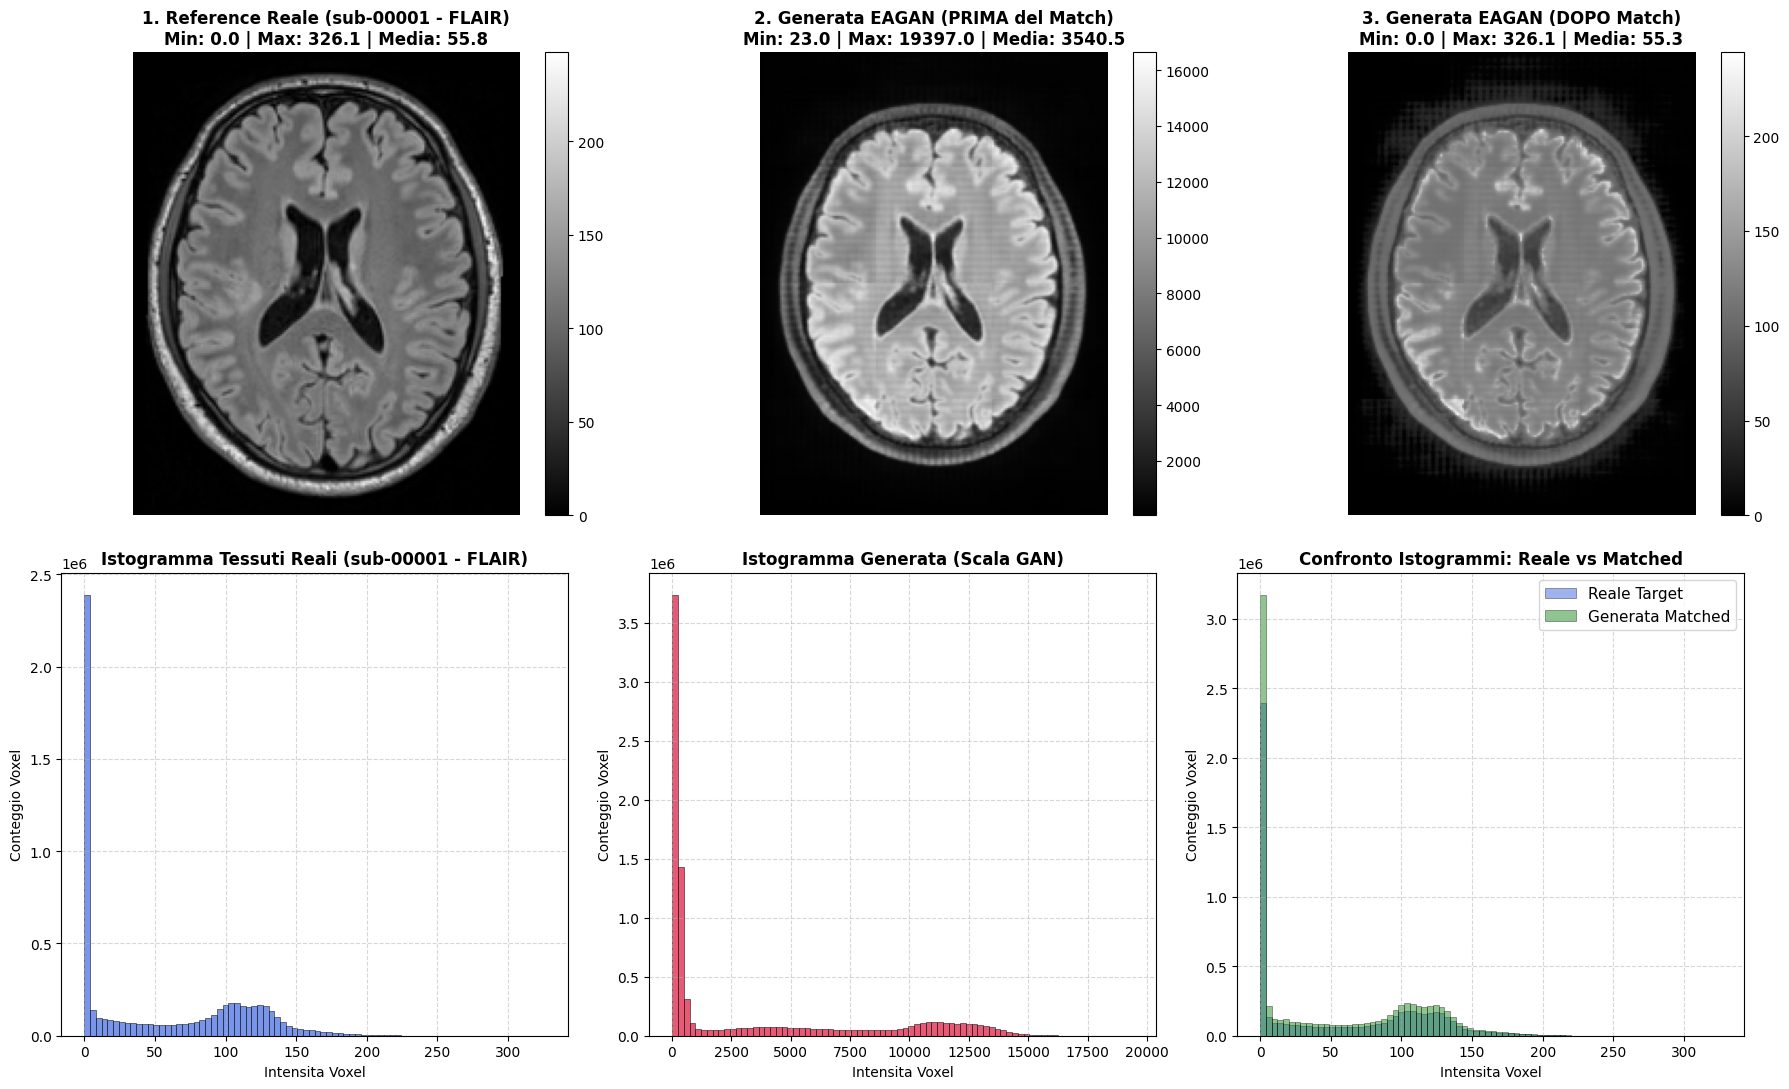


 AVVIO ESECUZIONE SEQUENZIALE DI 1 ESPERIMENTI

###########################################################################
 [ESPERIMENTO 1/1] Train Generato -> Val Generato (Sanity Check)
  - Modalita' Training:   only_generated
  - Validazione su:       IMMAGINI GENERATE
  - ID Salvataggio:       gen_train_gen_val
###########################################################################

--- [gen_train_gen_val] Esecuzione FOLD 1/5 ---
[Histogram Matching] Template reale (FLAIR) caricato con successo da: /kaggle/input/datasets/elenaschgor/dataset-2-t1-flair/ds004199_final/sub-00001/sub-00001_FLAIR_MNI152_1mm.nii
[TRAIN (Solo Generato) - FLAIR] Caricati 136 campioni su 136 soggetti attesi.
[Histogram Matching] Template reale (FLAIR) caricato con successo da: /kaggle/input/datasets/elenaschgor/dataset-2-t1-flair/ds004199_final/sub-00001/sub-00001_FLAIR_MNI152_1mm.nii
[VAL (Solo Generato) - FLAIR] Caricati 34 campioni su 34 soggetti attesi.
Epoca [1/150] | Train Loss (NLL): 0.6637 | V

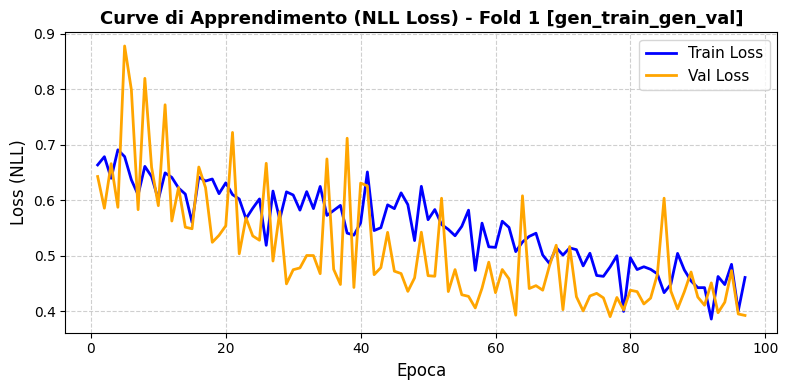

>>> [gen_train_gen_val] FOLD 1 COMPLETATA | Loss: 0.3900 | Salvato in: /kaggle/working/models/sfcn_gen_train_gen_val_fold_1.pth

>>> [gen_train_gen_val] FOLD 1 RESULTS
Accuracy : 0.8529
ROC-AUC  : 0.9273


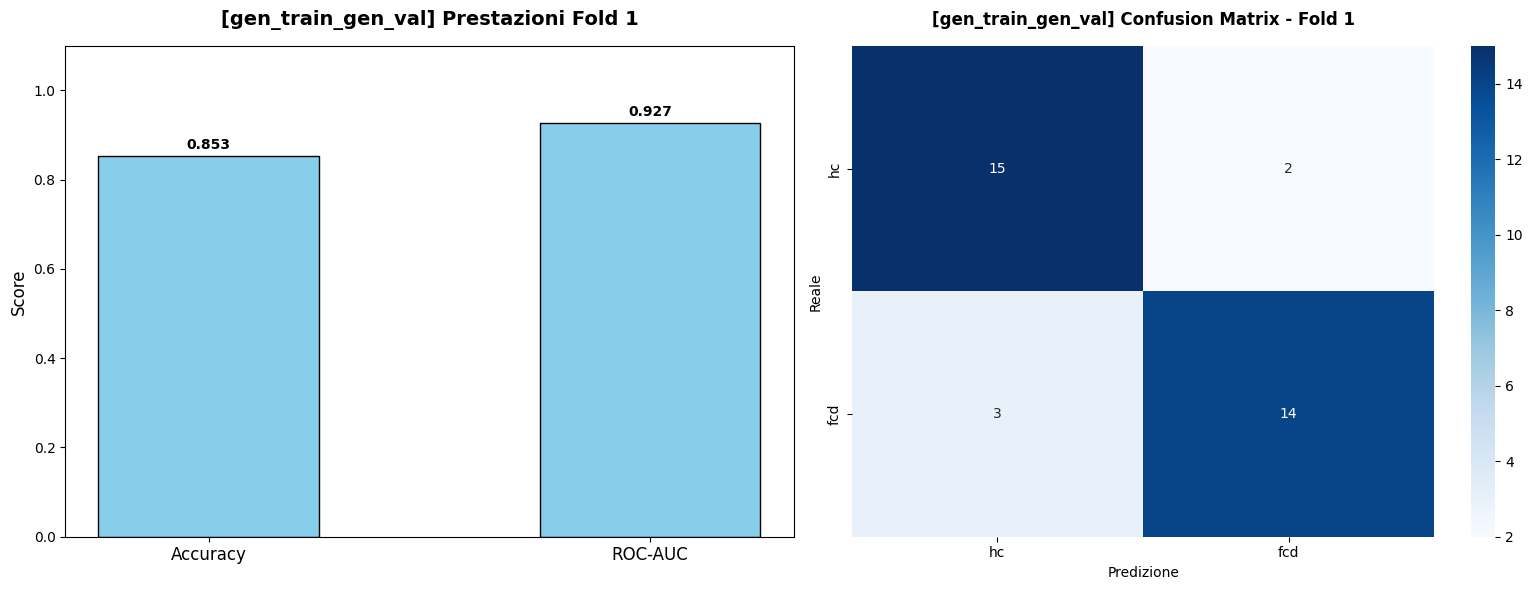


--- [gen_train_gen_val] Esecuzione FOLD 2/5 ---
[Histogram Matching] Template reale (FLAIR) caricato con successo da: /kaggle/input/datasets/elenaschgor/dataset-2-t1-flair/ds004199_final/sub-00001/sub-00001_FLAIR_MNI152_1mm.nii
[TRAIN (Solo Generato) - FLAIR] Caricati 136 campioni su 136 soggetti attesi.
[Histogram Matching] Template reale (FLAIR) caricato con successo da: /kaggle/input/datasets/elenaschgor/dataset-2-t1-flair/ds004199_final/sub-00001/sub-00001_FLAIR_MNI152_1mm.nii
[VAL (Solo Generato) - FLAIR] Caricati 34 campioni su 34 soggetti attesi.
Epoca [1/150] | Train Loss (NLL): 0.6744 | Val Loss: 0.6814
  --> Val Loss migliorata! Modello salvato. (Pazienza azzerata)
Epoca [2/150] | Train Loss (NLL): 0.7338 | Val Loss: 0.6754
  --> Val Loss migliorata! Modello salvato. (Pazienza azzerata)
Epoca [3/150] | Train Loss (NLL): 0.6734 | Val Loss: 0.6351
  --> Val Loss migliorata! Modello salvato. (Pazienza azzerata)
Epoca [4/150] | Train Loss (NLL): 0.6792 | Val Loss: 0.6482
  --> N

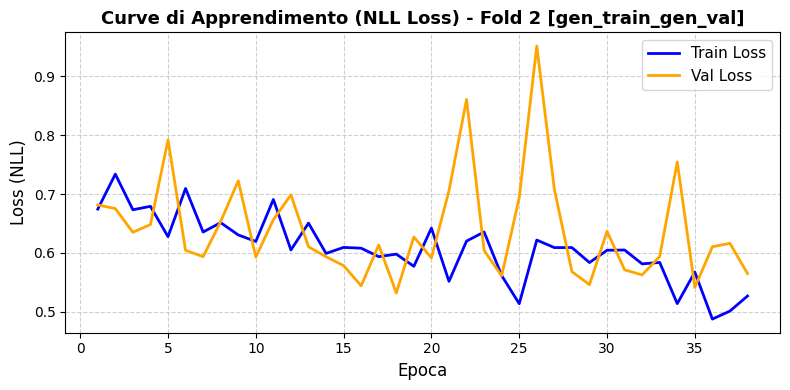

>>> [gen_train_gen_val] FOLD 2 COMPLETATA | Loss: 0.5321 | Salvato in: /kaggle/working/models/sfcn_gen_train_gen_val_fold_2.pth

>>> [gen_train_gen_val] FOLD 2 RESULTS
Accuracy : 0.6176
ROC-AUC  : 0.7993


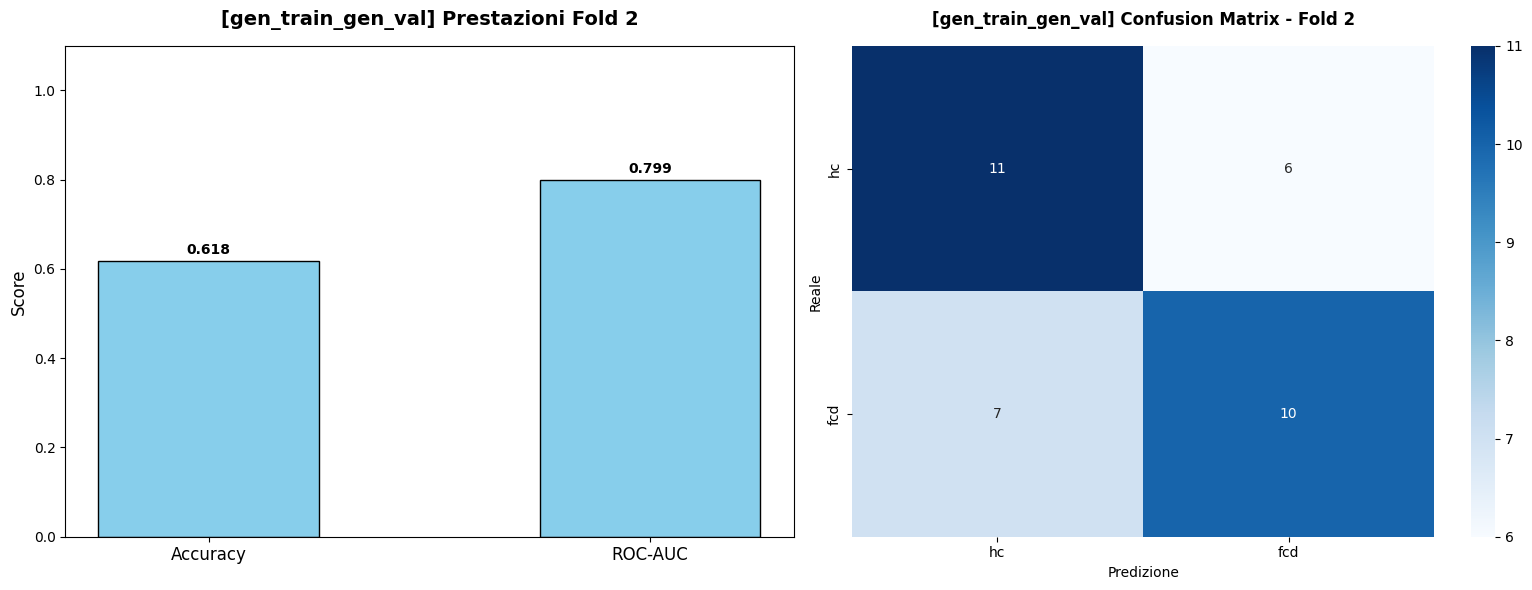


--- [gen_train_gen_val] Esecuzione FOLD 3/5 ---
[Histogram Matching] Template reale (FLAIR) caricato con successo da: /kaggle/input/datasets/elenaschgor/dataset-2-t1-flair/ds004199_final/sub-00001/sub-00001_FLAIR_MNI152_1mm.nii
[TRAIN (Solo Generato) - FLAIR] Caricati 136 campioni su 136 soggetti attesi.
[Histogram Matching] Template reale (FLAIR) caricato con successo da: /kaggle/input/datasets/elenaschgor/dataset-2-t1-flair/ds004199_final/sub-00001/sub-00001_FLAIR_MNI152_1mm.nii
[VAL (Solo Generato) - FLAIR] Caricati 34 campioni su 34 soggetti attesi.
Epoca [1/150] | Train Loss (NLL): 0.7080 | Val Loss: 0.6894
  --> Val Loss migliorata! Modello salvato. (Pazienza azzerata)
Epoca [2/150] | Train Loss (NLL): 0.6989 | Val Loss: 0.7113
  --> Nessun miglioramento. Pazienza: 1/20
Epoca [3/150] | Train Loss (NLL): 0.6743 | Val Loss: 0.6732
  --> Val Loss migliorata! Modello salvato. (Pazienza azzerata)
Epoca [4/150] | Train Loss (NLL): 0.6586 | Val Loss: 0.7825
  --> Nessun miglioramento. 

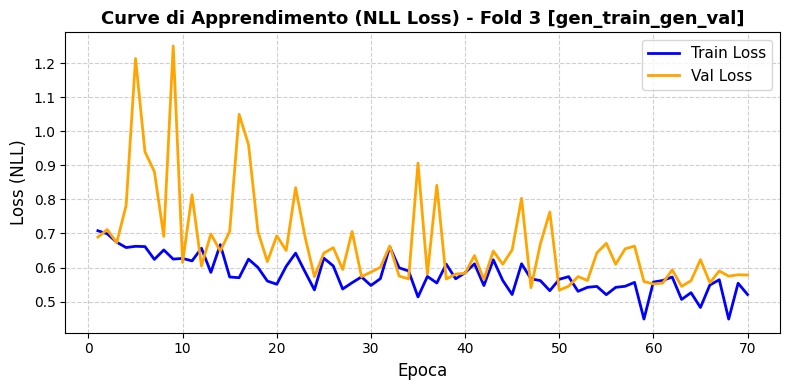

>>> [gen_train_gen_val] FOLD 3 COMPLETATA | Loss: 0.5335 | Salvato in: /kaggle/working/models/sfcn_gen_train_gen_val_fold_3.pth

>>> [gen_train_gen_val] FOLD 3 RESULTS
Accuracy : 0.7353
ROC-AUC  : 0.7716


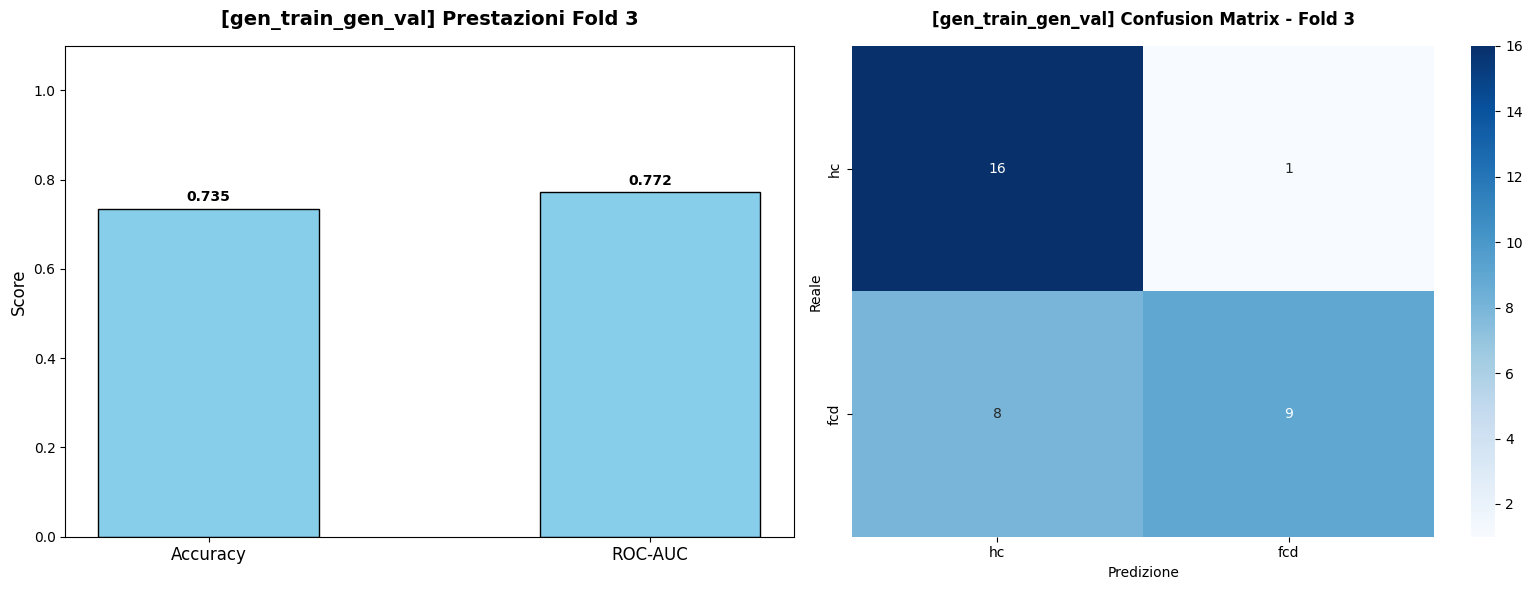


--- [gen_train_gen_val] Esecuzione FOLD 4/5 ---
[Histogram Matching] Template reale (FLAIR) caricato con successo da: /kaggle/input/datasets/elenaschgor/dataset-2-t1-flair/ds004199_final/sub-00001/sub-00001_FLAIR_MNI152_1mm.nii
[TRAIN (Solo Generato) - FLAIR] Caricati 136 campioni su 136 soggetti attesi.
[Histogram Matching] Template reale (FLAIR) caricato con successo da: /kaggle/input/datasets/elenaschgor/dataset-2-t1-flair/ds004199_final/sub-00001/sub-00001_FLAIR_MNI152_1mm.nii
[VAL (Solo Generato) - FLAIR] Caricati 34 campioni su 34 soggetti attesi.
Epoca [1/150] | Train Loss (NLL): 0.7214 | Val Loss: 0.6461
  --> Val Loss migliorata! Modello salvato. (Pazienza azzerata)
Epoca [2/150] | Train Loss (NLL): 0.7385 | Val Loss: 0.6747
  --> Nessun miglioramento. Pazienza: 1/20
Epoca [3/150] | Train Loss (NLL): 0.6886 | Val Loss: 0.5874
  --> Val Loss migliorata! Modello salvato. (Pazienza azzerata)
Epoca [4/150] | Train Loss (NLL): 0.6864 | Val Loss: 0.7366
  --> Nessun miglioramento. 

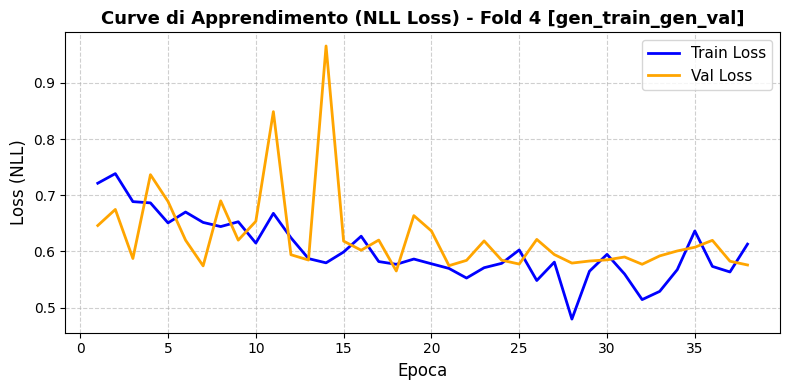

>>> [gen_train_gen_val] FOLD 4 COMPLETATA | Loss: 0.5652 | Salvato in: /kaggle/working/models/sfcn_gen_train_gen_val_fold_4.pth

>>> [gen_train_gen_val] FOLD 4 RESULTS
Accuracy : 0.7059
ROC-AUC  : 0.6851


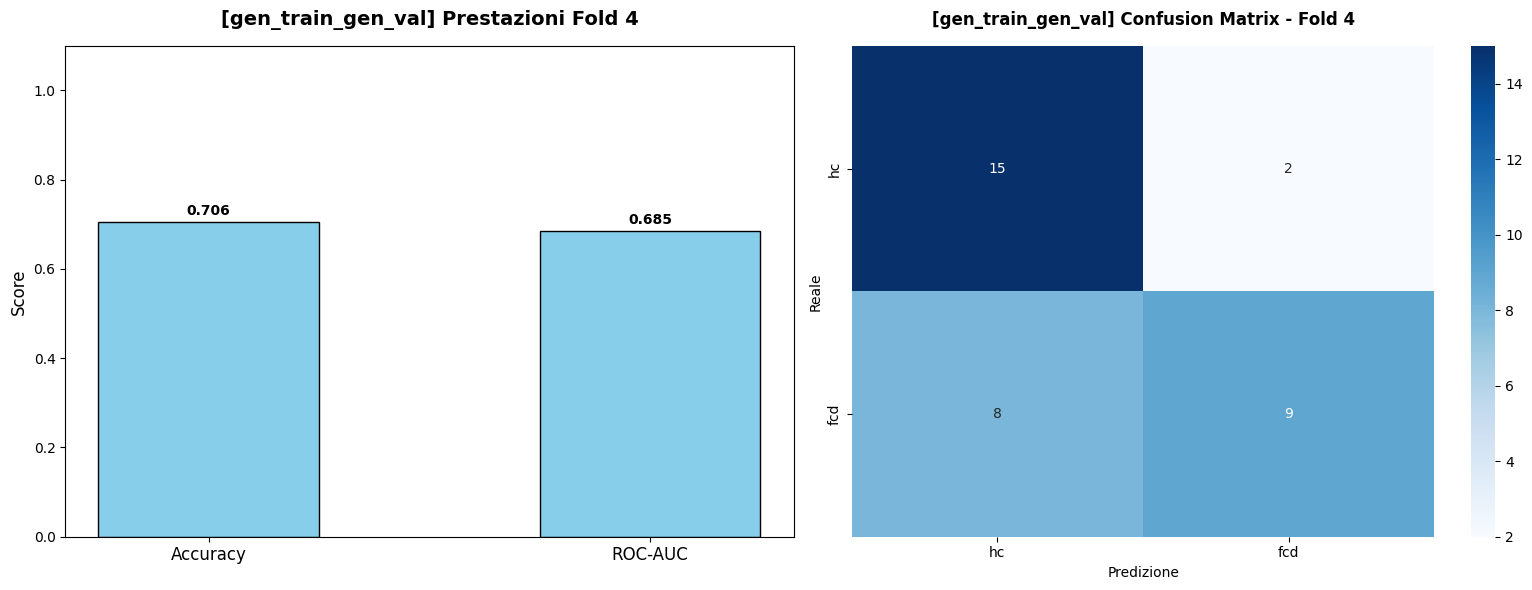


--- [gen_train_gen_val] Esecuzione FOLD 5/5 ---
[Histogram Matching] Template reale (FLAIR) caricato con successo da: /kaggle/input/datasets/elenaschgor/dataset-2-t1-flair/ds004199_final/sub-00001/sub-00001_FLAIR_MNI152_1mm.nii
[TRAIN (Solo Generato) - FLAIR] Caricati 136 campioni su 136 soggetti attesi.
[Histogram Matching] Template reale (FLAIR) caricato con successo da: /kaggle/input/datasets/elenaschgor/dataset-2-t1-flair/ds004199_final/sub-00001/sub-00001_FLAIR_MNI152_1mm.nii
[VAL (Solo Generato) - FLAIR] Caricati 34 campioni su 34 soggetti attesi.
Epoca [1/150] | Train Loss (NLL): 0.7386 | Val Loss: 0.7108
  --> Val Loss migliorata! Modello salvato. (Pazienza azzerata)
Epoca [2/150] | Train Loss (NLL): 0.7192 | Val Loss: 0.8522
  --> Nessun miglioramento. Pazienza: 1/20
Epoca [3/150] | Train Loss (NLL): 0.6474 | Val Loss: 1.8010
  --> Nessun miglioramento. Pazienza: 2/20
Epoca [4/150] | Train Loss (NLL): 0.6715 | Val Loss: 0.9224
  --> Nessun miglioramento. Pazienza: 3/20
Epoca 

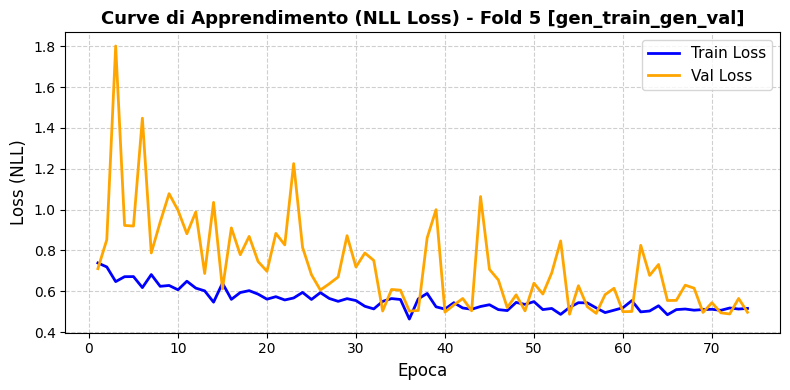

>>> [gen_train_gen_val] FOLD 5 COMPLETATA | Loss: 0.4875 | Salvato in: /kaggle/working/models/sfcn_gen_train_gen_val_fold_5.pth

>>> [gen_train_gen_val] FOLD 5 RESULTS
Accuracy : 0.7353
ROC-AUC  : 0.8062


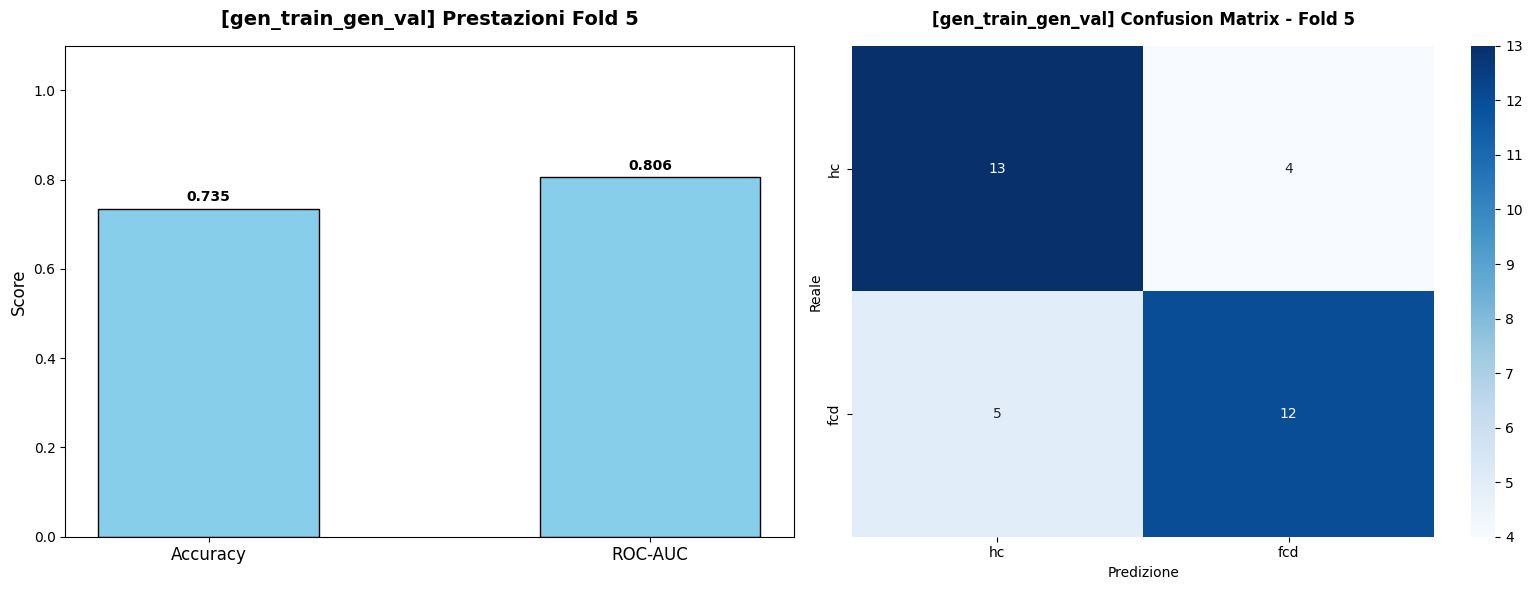


>>> [OK] Metriche esperimento 'Train Generato -> Val Generato (Sanity Check)' salvate in /kaggle/working/models/cv_metrics_gen_train_gen_val.csv


In [6]:
import os
import gc
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from skimage.exposure import match_histograms

def plot_histogram_matching_verification(real_data_dir, gen_data_dir, gen_model="eagan", 
                                         ref_subject_id="sub-00001", modality="T1w", save_dir="./plots"):
    os.makedirs(save_dir, exist_ok=True)
    
    # 1. Trova il soggetto reale di riferimento
    possible_subs = [ref_subject_id, "sub-00001", "sub-001"]
    ref_path = None
    actual_ref_sub = ref_subject_id
    for s in possible_subs:
        ref_path = find_real_file(real_data_dir, s, modality)
        if ref_path:
            actual_ref_sub = s
            break
            
    if not ref_path or not os.path.exists(ref_path):
        print(f"[Plot Verification] ATTENZIONE: Reference {ref_subject_id} per modalita' {modality} non trovato in {real_data_dir}.")
        return

    print(f"[Plot Verification] Caricato Reference Reale ({modality}) da: {ref_path}")
    real_img = nib.load(ref_path)
    real_data = real_img.get_fdata(dtype=np.float32)

    # 2. Trova un'immagine generata corrispondente
    gen_path = find_generated_file(gen_data_dir, actual_ref_sub, gen_model, modality)
    sample_sub = actual_ref_sub
    
    if not gen_path:
        _, direction, _, dst_tag = get_modality_info(modality)
        gen_dir = resolve_generated_dir(gen_data_dir, direction)
        if os.path.exists(gen_dir):
            try:
                for root, _, files in os.walk(gen_dir):
                    for f in sorted(files):
                        if f.endswith(('.nii', '.nii.gz')) and gen_model.lower() in f.lower() and dst_tag.lower() in f.lower():
                            gen_path = os.path.join(root, f)
                            sample_sub = f.split('_')[0]
                            break
                    if gen_path:
                        break
            except Exception:
                pass

    if not gen_path or not os.path.exists(gen_path):
        print(f"[Plot Verification] Immagine generata per il modello {gen_model} non trovata. Salto il plot.")
        return

    print(f"[Plot Verification] Caricata Immagine Generata ({sample_sub}) da: {gen_path}")
    gen_img = nib.load(gen_path)
    gen_data = gen_img.get_fdata(dtype=np.float32)

    # 3. Esegui Histogram Matching
    matched_data = match_histograms(gen_data, real_data).astype(np.float32)

    # Maschere del cervello (tessuto non-zero)
    mask_real = real_data > 0
    mask_gen = gen_data > 0
    mask_matched = matched_data > 0

    # 4. Generazione Figura
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    
    mid_slice_real = real_data.shape[2] // 2
    mid_slice_gen = gen_data.shape[2] // 2

    # Riga 1: Fette Assiali
    im0 = axes[0, 0].imshow(np.rot90(real_data[:, :, mid_slice_real]), cmap='gray')
    axes[0, 0].set_title(f'1. Reference Reale ({actual_ref_sub} - {modality})\nMin: {real_data.min():.1f} | Max: {real_data.max():.1f} | Media: {real_data[mask_real].mean():.1f}', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)

    im1 = axes[0, 1].imshow(np.rot90(gen_data[:, :, mid_slice_gen]), cmap='gray')
    axes[0, 1].set_title(f'2. Generata {gen_model.upper()} (PRIMA del Match)\nMin: {gen_data.min():.1f} | Max: {gen_data.max():.1f} | Media: {gen_data[mask_gen].mean():.1f}', fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

    im2 = axes[0, 2].imshow(np.rot90(matched_data[:, :, mid_slice_gen]), cmap='gray')
    axes[0, 2].set_title(f'3. Generata {gen_model.upper()} (DOPO Match)\nMin: {matched_data.min():.1f} | Max: {matched_data.max():.1f} | Media: {matched_data[mask_matched].mean():.1f}', fontsize=12, fontweight='bold')
    axes[0, 2].axis('off')
    plt.colorbar(im2, ax=axes[0, 2], fraction=0.046)

    # Riga 2: Istogrammi
    axes[1, 0].hist(real_data[mask_real], bins=80, color='royalblue', alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[1, 0].set_title(f'Istogramma Tessuti Reali ({actual_ref_sub} - {modality})', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Intensita Voxel')
    axes[1, 0].set_ylabel('Conteggio Voxel')
    axes[1, 0].grid(True, linestyle='--', alpha=0.5)

    axes[1, 1].hist(gen_data[mask_gen], bins=80, color='crimson', alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[1, 1].set_title(f'Istogramma Generata (Scala GAN)', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Intensita Voxel')
    axes[1, 1].set_ylabel('Conteggio Voxel')
    axes[1, 1].grid(True, linestyle='--', alpha=0.5)

    axes[1, 2].hist(real_data[mask_real], bins=80, color='royalblue', alpha=0.5, label='Reale Target', edgecolor='black', linewidth=0.5)
    axes[1, 2].hist(matched_data[mask_matched], bins=80, color='forestgreen', alpha=0.5, label='Generata Matched', edgecolor='black', linewidth=0.5)
    axes[1, 2].set_title('Confronto Istogrammi: Reale vs Matched', fontsize=12, fontweight='bold')
    axes[1, 2].set_xlabel('Intensita Voxel')
    axes[1, 2].set_ylabel('Conteggio Voxel')
    axes[1, 2].legend(fontsize=11)
    axes[1, 2].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    save_path = os.path.join(save_dir, 'histogram_matching_verification.png')
    plt.savefig(save_path, dpi=300)
    print(f"[Plot Verification] Grafico salvato con successo in: {save_path}")
    plt.show()

# ==============================================================================
# DEFINIZIONE LOSS FUNCTIONS AVANZATE
# ==============================================================================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, log_probs, targets):
        probs = torch.exp(log_probs)
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_weight = (1.0 - pt) ** self.gamma
        if self.alpha is not None:
            if not isinstance(self.alpha, torch.Tensor):
                alpha_t = torch.tensor(self.alpha, device=log_probs.device, dtype=torch.float32)
            else:
                alpha_t = self.alpha.to(log_probs.device)
            focal_weight = alpha_t.gather(0, targets) * focal_weight
        loss = -focal_weight * log_pt
        if self.reduction == 'mean': return loss.mean()
        elif self.reduction == 'sum': return loss.sum()
        return loss

class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, epsilon=0.1, reduction='mean'):
        super().__init__()
        self.epsilon = epsilon
        self.reduction = reduction

    def forward(self, log_probs, targets):
        n_classes = log_probs.size(1)
        one_hot = torch.zeros_like(log_probs).scatter_(1, targets.unsqueeze(1), 1.0)
        smooth_targets = one_hot * (1.0 - self.epsilon) + (self.epsilon / n_classes)
        loss = -torch.sum(smooth_targets * log_probs, dim=1)
        if self.reduction == 'mean': return loss.mean()
        elif self.reduction == 'sum': return loss.sum()
        return loss

class FocalLabelSmoothingLoss(nn.Module):
    def __init__(self, gamma=2.0, epsilon=0.1, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.epsilon = epsilon
        self.reduction = reduction

    def forward(self, log_probs, targets):
        n_classes = log_probs.size(1)
        probs = torch.exp(log_probs)
        one_hot = torch.zeros_like(log_probs).scatter_(1, targets.unsqueeze(1), 1.0)
        smooth_targets = one_hot * (1.0 - self.epsilon) + (self.epsilon / n_classes)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_weight = ((1.0 - pt) ** self.gamma).unsqueeze(1)
        loss = -torch.sum(focal_weight * smooth_targets * log_probs, dim=1)
        if self.reduction == 'mean': return loss.mean()
        elif self.reduction == 'sum': return loss.sum()
        return loss

def get_loss_criterion(loss_type=None, gamma=2.0, epsilon=0.1, alpha=None, device=None):
    l_type = (loss_type or globals().get('LOSS_TYPE', 'FOCAL')).upper()
    if l_type == 'FOCAL':
        crit = FocalLoss(gamma=gamma, alpha=alpha)
    elif l_type == 'LABEL_SMOOTHING':
        crit = LabelSmoothingCrossEntropy(epsilon=epsilon)
    elif l_type == 'FOCAL_SMOOTHED':
        crit = FocalLabelSmoothingLoss(gamma=gamma, epsilon=epsilon)
    elif l_type == 'WEIGHTED_NLL':
        w = torch.tensor(alpha, device=device, dtype=torch.float32) if alpha is not None else None
        crit = nn.NLLLoss(weight=w)
    else:
        crit = nn.NLLLoss()
    if device is not None:
        crit = crit.to(device)
    return crit

def train_binary_model(model, train_loader, val_loader, device, fold=None, exp_id=None):
    curr_loss_name = globals().get('LOSS_TYPE', 'FOCAL').upper()
    criterion = get_loss_criterion(
        loss_type=curr_loss_name,
        gamma=globals().get('FOCAL_GAMMA', 2.0),
        epsilon=globals().get('LABEL_SMOOTHING_EPS', 0.1),
        alpha=globals().get('CLASS_WEIGHTS', None),
        device=device
    )
    
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = optim.AdamW(trainable_params, lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7)
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None
    train_history = []
    val_history = []
    
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)[0].reshape(inputs.size(0), -1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)[0].reshape(inputs.size(0), -1)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_val_loss = val_loss / len(val_loader.dataset)
        train_history.append(epoch_train_loss)
        val_history.append(epoch_val_loss)
        
        # Stampa ad ogni epoca
        print(f"Epoca [{epoch+1}/{EPOCHS}] | Train Loss ({curr_loss_name}): {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
        
        scheduler.step(epoch_val_loss)
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
            best_model_state = {k: v.cpu() for k, v in model.state_dict().items()}
            print(f"  --> Val Loss migliorata! Modello salvato. (Pazienza azzerata)")
        else:
            epochs_no_improve += 1
            print(f"  --> Nessun miglioramento. Pazienza: {epochs_no_improve}/{PATIENCE}")
            if epochs_no_improve >= PATIENCE:
                print(f"\n[!] EARLY STOPPING attivato all'epoca {epoch+1}. Raggiunta pazienza massima ({PATIENCE}).")
                break
                
    model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
    
    # Plot delle curve di apprendimento (Train Loss vs Val Loss per epoca)
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(train_history)+1), train_history, label='Train Loss', color='blue', linewidth=2)
    plt.plot(range(1, len(val_history)+1), val_history, label='Val Loss', color='orange', linewidth=2)
    plt.xlabel('Epoca', fontsize=12)
    plt.ylabel(f'Loss ({curr_loss_name})', fontsize=12)
    title_suffix = f' - Fold {fold}' if fold is not None else ''
    exp_suffix = f' [{exp_id}]' if exp_id is not None else ''
    plt.title(f'Curve di Apprendimento ({curr_loss_name} Loss){title_suffix}{exp_suffix}', fontsize=13, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    plot_fn = f'training_curves_{exp_id}_fold_{fold}.png' if (exp_id and fold) else f'training_curves_fold_{fold}.png'
    plt.savefig(os.path.join(PLOTS_DIR, plot_fn), dpi=300)
    plt.show()
    
    return model, best_val_loss

def evaluate_and_plot(model, dataloader, device, fold_idx, class_names, exp_id=None):
    model.eval()
    true_labels = []
    probs_1 = []
    preds = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            true_labels.append(labels.item())
            
            out = model(inputs)[0].reshape(inputs.size(0), -1)
            prob = torch.exp(out)
            probs_1.append(prob[0, 1].item())
            preds.append(torch.argmax(prob, dim=1).item())
            
    acc = accuracy_score(true_labels, preds)
    try:
        auc = roc_auc_score(true_labels, probs_1)
    except:
        auc = float('nan')
        
    tag = f"[{exp_id}] " if exp_id else ""
    print(f"\n>>> {tag}FOLD {fold_idx} RESULTS")
    print(f"Accuracy : {acc:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    
    # Plotting for fold
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar Chart
    labels = ['Accuracy', 'ROC-AUC']
    scores = [acc, auc]
    x = np.arange(len(labels))
    width = 0.5
    
    rects = ax1.bar(x, scores, width, color='skyblue', edgecolor='black')
    ax1.set_ylabel('Score', fontsize=12)
    ax1.set_title(f'{tag}Prestazioni Fold {fold_idx}', fontsize=14, fontweight='bold', pad=15)
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, fontsize=12)
    ax1.set_ylim(0, 1.1)
    
    for rect in rects:
        height = rect.get_height()
        if not np.isnan(height):
            ax1.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')
    
    # Confusion Matrix
    cm = confusion_matrix(true_labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax2)
    ax2.set_title(f"{tag}Confusion Matrix - Fold {fold_idx}", fontweight='bold', pad=15)
    ax2.set_xlabel("Predizione")
    ax2.set_ylabel("Reale")
    
    plt.tight_layout()
    res_fn = f'fold_{fold_idx}_{exp_id}_results.png' if exp_id else f'fold_{fold_idx}_results.png'
    plt.savefig(os.path.join(PLOTS_DIR, res_fn), dpi=300)
    plt.show()
    
    return acc, auc

# ==============================================================================
# ESECUZIONE SEQUENZIALE DEGLI ESPERIMENTI
# ==============================================================================
all_experiments_results = {}

if df_splits is not None:
    # Plot di verifica dell'Histogram Matching (se attivo)
    if APPLY_HISTOGRAM_MATCHING:
        print("\nGenerazione grafico di verifica Histogram Matching (Prima e Dopo)...")
        plot_histogram_matching_verification(
            real_data_dir=KAGGLE_DATA_DIR,
            gen_data_dir=GENERATED_DATA_DIR,
            gen_model=GENERATIVE_MODEL,
            ref_subject_id=REF_SUBJECT_ID,
            modality=MODALITY,
            save_dir=PLOTS_DIR
        )

    print("\n" + "=" * 75)
    print(f" AVVIO ESECUZIONE SEQUENZIALE DI {len(EXPERIMENTS_TO_RUN)} ESPERIMENTI")
    print("=" * 75)
    
    for exp_idx, exp_cfg in enumerate(EXPERIMENTS_TO_RUN, 1):
        exp_id = exp_cfg['id']
        exp_name = exp_cfg['name']
        train_mode = exp_cfg['train_mode']
        validate_on_gen = exp_cfg['validate_on_gen']
        
        print("\n" + "#" * 75)
        print(f" [ESPERIMENTO {exp_idx}/{len(EXPERIMENTS_TO_RUN)}] {exp_name}")
        print(f"  - Modalita' Training:   {train_mode}")
        print(f"  - Validazione su:       {'IMMAGINI GENERATE' if validate_on_gen else 'IMMAGINI REALI'}")
        print(f"  - ID Salvataggio:       {exp_id}")
        print("#" * 75)
        
        exp_fold_metrics = []
        exp_val_losses = []
        exp_models_paths = []
        
        for fold in range(1, K_FOLDS + 1):
            print(f"\n--- [{exp_id}] Esecuzione FOLD {fold}/{K_FOLDS} ---")
            
            fold_df = df_splits[df_splits['Fold'] == fold]
            train_df = fold_df[fold_df['Split'] == 'Train']
            val_df = fold_df[fold_df['Split'] == 'Validation']
            
            # Train dataset per l'esperimento corrente
            fold_train_dataset = OpenNeuroFCDDataset(
                df=train_df, 
                real_data_dir=KAGGLE_DATA_DIR,
                gen_data_dir=GENERATED_DATA_DIR, 
                is_train=True, 
                train_mode=train_mode, 
                gen_model=GENERATIVE_MODEL, 
                modality=MODALITY,
                apply_hist_match=APPLY_HISTOGRAM_MATCHING,
                ref_subject_id=REF_SUBJECT_ID
            )
            
            # Validation dataset per l'esperimento corrente
            fold_val_dataset = OpenNeuroFCDDataset(
                df=val_df, 
                real_data_dir=KAGGLE_DATA_DIR,
                gen_data_dir=GENERATED_DATA_DIR,
                is_train=False, 
                validate_on_gen=validate_on_gen, 
                gen_model=GENERATIVE_MODEL,
                modality=MODALITY,
                apply_hist_match=APPLY_HISTOGRAM_MATCHING if validate_on_gen else False,
                ref_subject_id=REF_SUBJECT_ID
            )
            
            # Sampler Bilanciamento
            fold_train_labels = [sample['label'] for sample in fold_train_dataset.samples]
            if len(fold_train_labels) > 0:
                class_counts = np.bincount(fold_train_labels, minlength=OUTPUT_DIM)
                weights = [1.0 / class_counts[c] if class_counts[c] > 0 else 0 for c in fold_train_labels]
                sampler = WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)
                fold_train_loader = DataLoader(fold_train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
            else:
                print(f"ERRORE [{exp_id}]: Dataset di Training vuoto! Salto la fold.")
                continue
                
            fold_val_loader = DataLoader(fold_val_dataset, batch_size=1, shuffle=False, num_workers=2)
            
            # Inizializzazione SFCN da zero per la fold
            model = SFCN(output_dim=OUTPUT_DIM, channel_number=CUSTOM_CHANNELS)
            if torch.cuda.device_count() > 1:
                model = nn.DataParallel(model)
            model = model.to(device)
            
            trained_model, best_val_loss = train_binary_model(
                model, fold_train_loader, fold_val_loader, device, fold=fold, exp_id=exp_id
            )
            exp_val_losses.append(best_val_loss)
            
            # Salvataggio checkpoint con prefisso univoco
            model_save_path = os.path.join(MODELS_DIR, f"sfcn_{exp_id}_fold_{fold}.pth")
            if isinstance(trained_model, nn.DataParallel):
                torch.save(trained_model.module.state_dict(), model_save_path)
            else:
                torch.save(trained_model.state_dict(), model_save_path)
            
            exp_models_paths.append(model_save_path)
            print(f">>> [{exp_id}] FOLD {fold} COMPLETATA | Loss: {best_val_loss:.4f} | Salvato in: {model_save_path}")
            
            # Valutazione
            acc, auc = evaluate_and_plot(
                trained_model, fold_val_loader, device, fold, class_names, exp_id=exp_id
            )
            exp_fold_metrics.append({'acc': acc, 'auc': auc})
            
            # Pulizia esplicita VRAM GPU
            del model, trained_model
            del fold_train_loader, fold_val_loader
            del fold_train_dataset, fold_val_dataset
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                
        # Salvataggio metriche per questo esperimento
        if exp_fold_metrics:
            exp_avg_acc = np.mean([m['acc'] for m in exp_fold_metrics])
            exp_avg_auc = np.mean([m['auc'] for m in exp_fold_metrics])
            
            results_df = pd.DataFrame(exp_fold_metrics)
            results_df.index = [f"Fold_{i+1}" for i in range(len(exp_fold_metrics))]
            results_df.loc['Average'] = [exp_avg_acc, exp_avg_auc]
            
            csv_path = os.path.join(MODELS_DIR, f"cv_metrics_{exp_id}.csv")
            results_df.to_csv(csv_path, index=True, index_label='Fold')
            print(f"\n>>> [OK] Metriche esperimento '{exp_name}' salvate in {csv_path}")
            
            all_experiments_results[exp_id] = {
                'name': exp_name,
                'train_mode': train_mode,
                'validate_on_gen': validate_on_gen,
                'avg_acc': exp_avg_acc,
                'avg_auc': exp_avg_auc,
                'fold_metrics': exp_fold_metrics,
                'models_paths': exp_models_paths
            }


## 5. Risultati Medi 5-Fold Cross Validation


 RIEPILOGO COMPARATIVO FINALE - TUTTI GLI ESPERIMENTI

                                  Esperimento     Train Mode  Val Set Average Accuracy Average ROC-AUC
Train Generato -> Val Generato (Sanity Check) only_generated Generato  72.94% (0.7294)          0.7979

>>> Tabella comparativa salvata in: /kaggle/working/models/final_experiments_comparison_summary.csv
>>> Grafico comparativo salvato in: /kaggle/working/plots/comparison_all_experiments.png


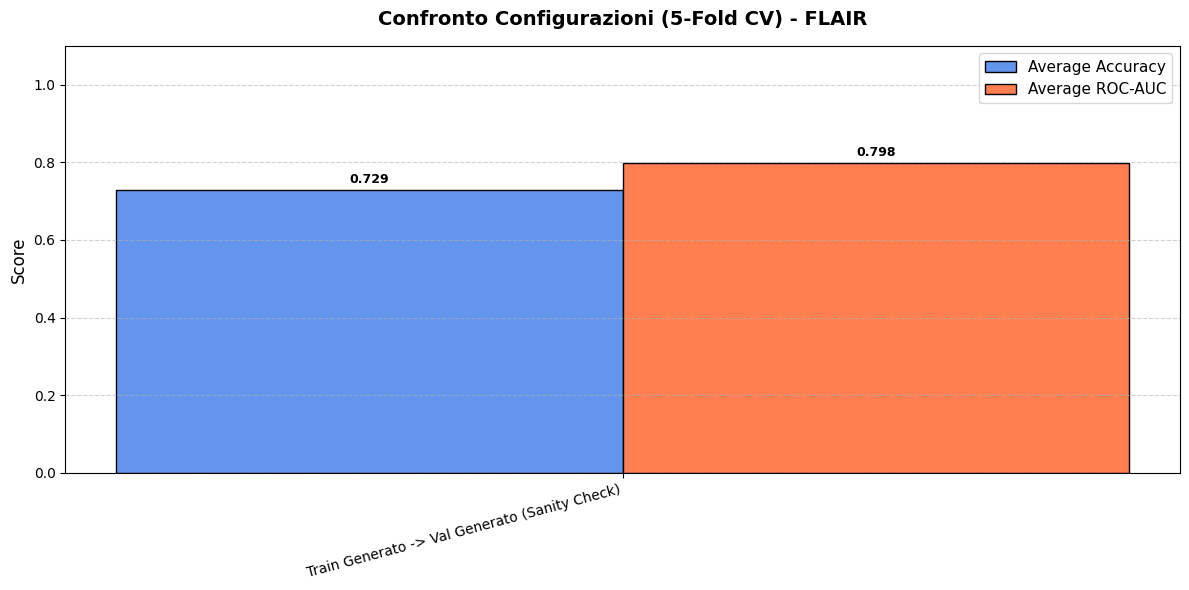

In [7]:
print("\n" + "=" * 75)
print(" RIEPILOGO COMPARATIVO FINALE - TUTTI GLI ESPERIMENTI")
print("=" * 75)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if 'all_experiments_results' in globals() and all_experiments_results:
    summary_rows = []
    for exp_id, data in all_experiments_results.items():
        summary_rows.append({
            'Esperimento': data['name'],
            'Train Mode': data['train_mode'],
            'Val Set': 'Generato' if data['validate_on_gen'] else 'Reale',
            'Average Accuracy': data['avg_acc'],
            'Average ROC-AUC': data['avg_auc']
        })
        
    summary_df = pd.DataFrame(summary_rows)
    
    # Stampa formattata a console
    summary_df_print = summary_df.copy()
    summary_df_print['Average Accuracy'] = summary_df_print['Average Accuracy'].apply(lambda x: f"{x*100:.2f}% ({x:.4f})")
    summary_df_print['Average ROC-AUC'] = summary_df_print['Average ROC-AUC'].apply(lambda x: f"{x:.4f}")
    print("\n" + summary_df_print.to_string(index=False))
    
    # Salvataggio CSV riassuntivo finale
    summary_csv_path = os.path.join(MODELS_DIR, 'final_experiments_comparison_summary.csv')
    summary_df.to_csv(summary_csv_path, index=False)
    print(f"\n>>> Tabella comparativa salvata in: {summary_csv_path}")
    
    # Grafico comparativo multi-bar finale
    exp_names = [d['name'] for d in all_experiments_results.values()]
    acc_scores = [d['avg_acc'] for d in all_experiments_results.values()]
    auc_scores = [d['avg_auc'] for d in all_experiments_results.values()]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(exp_names))
    width = 0.35
    
    rects1 = ax.bar(x - width/2, acc_scores, width, label='Average Accuracy', color='cornflowerblue', edgecolor='black')
    rects2 = ax.bar(x + width/2, auc_scores, width, label='Average ROC-AUC', color='coral', edgecolor='black')
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'Confronto Configurazioni ({K_FOLDS}-Fold CV) - {MODALITY}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(exp_names, fontsize=10, rotation=15, ha='right')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    for rects in [rects1, rects2]:
        for rect in rects:
            height = rect.get_height()
            if not np.isnan(height):
                ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=9)
                
    plt.tight_layout()
    comp_plot_path = os.path.join(PLOTS_DIR, 'comparison_all_experiments.png')
    plt.savefig(comp_plot_path, dpi=300)
    print(f">>> Grafico comparativo salvato in: {comp_plot_path}")
    plt.show()

elif 'fold_metrics' in globals() and fold_metrics:
    avg_acc = np.mean([m['acc'] for m in fold_metrics])
    avg_auc = np.mean([m['auc'] for m in fold_metrics])
    print(f"\n>>> MEDIA SULLE {K_FOLDS} FOLD")
    print(f"Average Accuracy : {avg_acc:.4f}")
    print(f"Average ROC-AUC  : {avg_auc:.4f}")
